# Free-Field Site Response with PM4Sand

A layered liquefiable soil profile sits on an elastic half-space and an earthquake motion arrives from below. The OpenSees model uses SSPquadUP elements for coupled soil and pore water, the PM4Sand constitutive model (Boulanger and Ziotopoulou 2017) for the liquefiable layers, and a viscous damper at the base for the half-space's finite rigidity.

<img src="schematic.png" width="200" align="center">

This notebook runs the model as a DesignSafe job with [dapi](https://designsafe-ci.github.io/dapi/) and plots the response, accelerations and their spectra, profiles of peak response, and the excess pore pressures that signal liquefaction. The model and plotting scripts come from the University of Washington's freeFieldJupyterPM4Sand example by the Arduino group.

In [ ]:
%pip install --quiet --upgrade dapi

**Restart the kernel once after the install**, then run from the next cell.

In [1]:
from dapi import DSClient

ds = DSClient()

/Users/krishna/dev/DesignSafe/Dapi-Tapis/dapi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Authentication successful.


TMS credentials ready: frontera, stampede3


## The model inputs

The folder beside this notebook holds everything the job needs. `N10_T3.tcl` builds and analyzes the soil column, and `velocity.input` is the input motion it reads.

Docs: [Path translation](https://designsafe-ci.github.io/dapi/files#path-translation).

In [2]:
import os

input_dir = os.getcwd()
try:
    input_uri = ds.files.to_uri(input_dir)  # on DesignSafe JupyterHub
except ValueError:
    # anywhere else: dapi uploads the folder to MyData once and stages from there
    prep = ds.jobs.prepare_inputs("opensees-s3", input_dir)
    input_uri = ds.files.to_uri(prep["staged_dir"])
print("Input URI:", input_uri)

Uploading staged files to tapis://designsafe.storage.default/kks32/dapi-staging/pm4sand (Tapis files API)


Uploaded 15 file(s); staged_dir is tapis://designsafe.storage.default/kks32/dapi-staging/pm4sand


Input URI: tapis://designsafe.storage.default/kks32/dapi-staging/pm4sand


## Submit the OpenSees job on Stampede3

The `opensees-s3` app serves the serial and parallel OpenSees binaries through one definition, so the job names its program, `OpenSees` here since the model is serial, and one core of one node is enough for a soil column.

Docs: [Job Submission](https://designsafe-ci.github.io/dapi/jobs#job-submission) and [Job Monitoring](https://designsafe-ci.github.io/dapi/jobs#job-monitoring).

In [3]:
allocation = "DS-Portal-SPARC2026"  # <-- replace with your allocation

job = ds.jobs.generate(
    app_id="opensees-s3",
    input_dir_uri=input_uri,
    script_filename="N10_T3.tcl",
    node_count=1,
    cores_per_node=1,
    max_minutes=60,
    queue="skx-dev",
    allocation=allocation,
    extra_app_args=[{"name": "Main Program", "arg": "OpenSees"}],
)
job["name"] = "pm4sand-freefield-s3"

submitted = ds.jobs.submit(job)
final = submitted.monitor(interval=30)
ds.jobs.interpret_status(final, submitted.uuid)
submitted.print_runtime_summary()

Job submitted successfully. UUID: ddedcf22-ea14-4f96-97da-dc095d6e0608-007



Monitoring Job: ddedcf22-ea14-4f96-97da-dc095d6e0608-007


Waiting for job to start: 0 checks [00:00, ? checks/s]

Waiting for job to start: 0 checks [00:00, ? checks/s, Status: PENDING]

Waiting for job to start: 1 checks [00:30, 30.11s/ checks, Status: PENDING]

...

Monitoring job (Status: ARCHIVING):   3%|▎         | 4/120 [01:30<47:34, 24.60s/ checks]

Monitoring job (Status: ARCHIVING):   3%|▎         | 4/120 [02:00<47:34, 24.60s/ checks]

Monitoring job (Status: ARCHIVING): 100%|██████████| 120/120 [02:00<00:00, 24.60s/ checks]

Monitoring job (Status: ARCHIVING): 100%|██████████| 120/120 [02:00<00:00,  1.00s/ checks]

	Status: FINISHED
Job ddedcf22-ea14-4f96-97da-dc095d6e0608-007 completed successfully.

Runtime Summary
---------------
QUEUED  time: 00:00:01
RUNNING time: 00:00:57
TOTAL   time: 00:03:57
---------------


Without an allocation, the same model runs on a DesignSafe virtual machine through `opensees-express`, no queue and no allocation, one shared machine.

```python
job = ds.jobs.generate(
    app_id="opensees-express",
    input_dir_uri=input_uri,
    script_filename="N10_T3.tcl",
    max_minutes=60,
)
```

## The archived outputs

The recorders write accelerations, displacements, pore pressures, stresses, and strains, and Tapis archives them with the job.

Docs: [Output Management](https://designsafe-ci.github.io/dapi/jobs#output-management) and [List files](https://designsafe-ci.github.io/dapi/files#list-files).

In [4]:
archive_uri = submitted.archive_uri


# The recorders write beside the model, so the results sit in the staged
# input folder inside the archive; search the root, then each subfolder.
# The plots need the recorder .out files and the model's node and element
# tables (.dat); tapisjob.out is the job log, not a recorder.
def _results(uri):
    return [
        it.name
        for it in ds.files.list(uri)
        if (it.name.endswith(".out") or it.name.endswith(".dat"))
        and not it.name.startswith("tapisjob")
    ]


candidates = [archive_uri] + [
    f"{archive_uri}/{it.name}" for it in ds.files.list(archive_uri) if it.type == "dir"
]
for results_uri in candidates:
    outputs = _results(results_uri)
    if outputs:
        break
print(len(outputs), "result files in", results_uri)

12 result files in tapis://stampede3/work2/05873/kks32/stampede3/tapis-jobs-archive/2026-08-12Z/pm4sand-freefield-s3-ddedcf22-ea14-4f96-97da-dc095d6e0608-007/inputDirectory


## Download the results

On DesignSafe JupyterHub the archive is a local folder; anywhere else the recorder files download once.

In [5]:
from pathlib import Path

mydata = Path.home() / "MyData"
work_root = mydata if mydata.is_dir() else Path.cwd()

results_dir = ds.files.to_path(results_uri)
if not os.path.isdir(results_dir):
    results_dir = str(work_root / "pm4sand_results")
    os.makedirs(results_dir, exist_ok=True)
    for name in outputs:
        ds.files.download(f"{results_uri}/{name}", f"{results_dir}/{name}")
print("plotting from", results_dir)

plotting from /Users/krishna/MyData/pm4sand_results


## Acceleration and response spectra

The surface accelerates far more than the base, and the response spectra show where the soil column amplifies the motion.

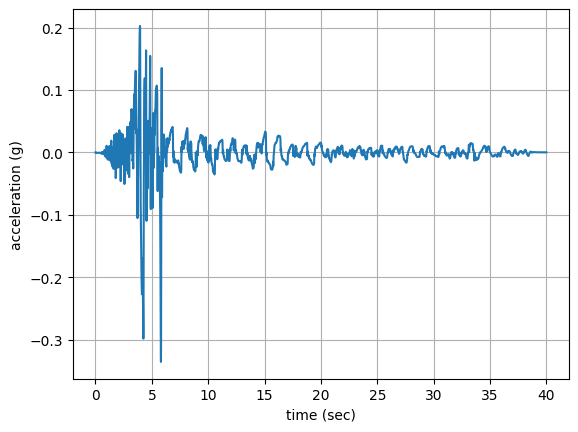

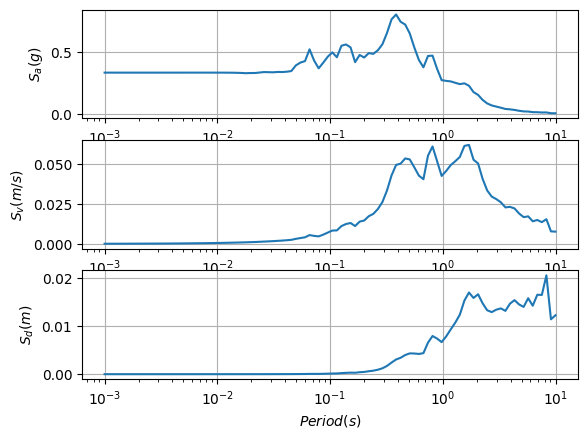

In [6]:
%matplotlib inline
from plotAcc import plot_acc

plot_acc(results_dir)

## Profiles through the soil column

Peak displacement, acceleration, shear strain, and stress ratio, layer by layer. The strain concentration marks the liquefying layer.

/Users/krishna/dev/DesignSafe/Dapi-Tapis/dapi/examples/opensees/pm4sand/plotProfile.py:80: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$(\\tau / \sigma_{v0})_{max} $")


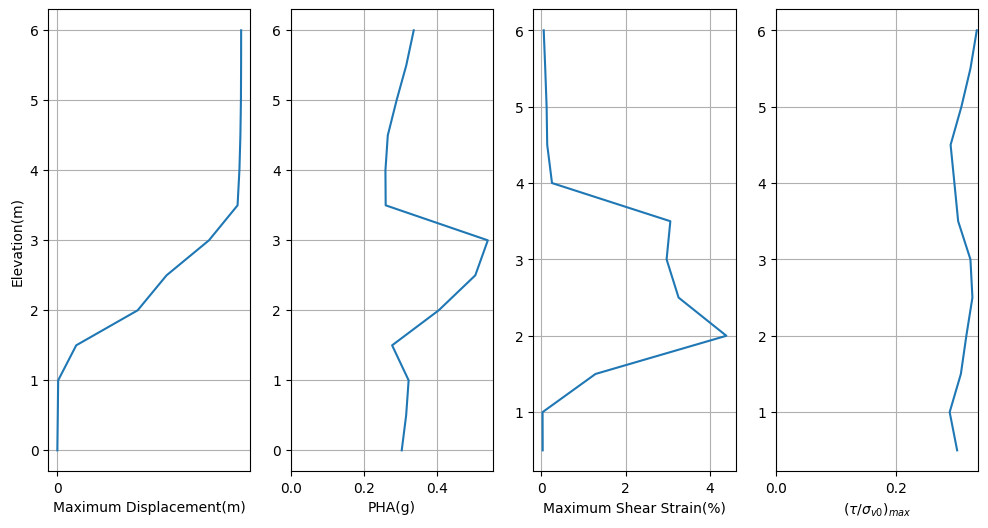

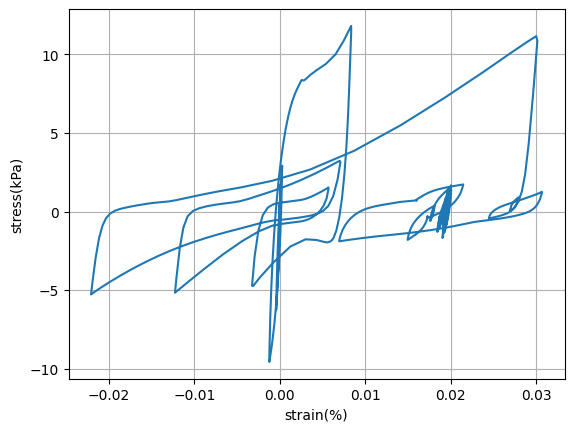

In [7]:
from plotProfile import plot_profile

plot_profile(results_dir)

## Excess pore pressure

Pore pressure ratios approaching 1.0 mean the effective stress has vanished, which is liquefaction. Watch where in the profile and when in the motion it happens.

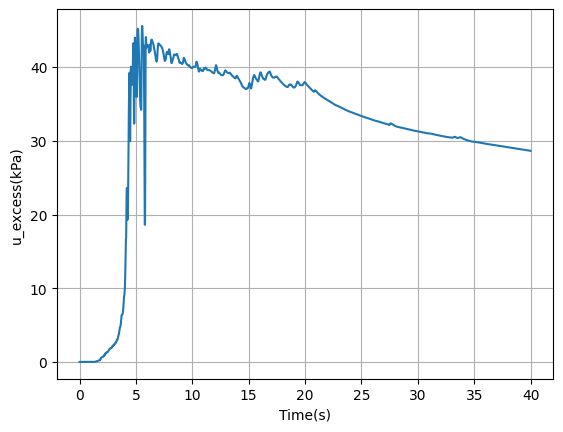

In [8]:
from plotPorepressure import plot_porepressure

plot_porepressure(results_dir)

## Explore the response interactively

On a live kernel, two widgets animate the response through the motion, the pore pressure trace and the deforming displacement profile, with a time slider. Run them on JupyterHub, where the kernel is live; a saved copy only shows a static frame.

```python
from interactiveplot import createpwpplot, createDispplot

createpwpplot(results_dir)
createDispplot(results_dir)
```